# Statistical Analysis

## Objective

This notebook performs statistical hypothesis testing to identify
whether important e-commerce relationships observed during EDA
are statistically significant.

## Imports

In [47]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import (
    ttest_ind,
    shapiro,
    levene,
    chi2_contingency,
    spearmanr,
    pearsonr
)

from statsmodels.stats.oneway import anova_oneway

from sqlalchemy import create_engine, text
from dotenv import load_dotenv

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")

ALPHA = 0.05

print("Libraries imported successfully.")


Libraries imported successfully.


## Database Connection

In [48]:
load_dotenv()

MYSQL_HOST = os.getenv("MYSQL_HOST")
MYSQL_PORT = os.getenv("MYSQL_PORT", "3306")
MYSQL_USER = os.getenv("MYSQL_USER")
MYSQL_PASSWORD = os.getenv("MYSQL_PASSWORD")
MYSQL_DATABASE = os.getenv("MYSQL_DATABASE")

connection_url = (
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}"
    f"@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}"
)

engine = create_engine(connection_url)

with engine.connect() as connection:
    result = connection.execute(text("SELECT DATABASE();"))
    current_database = result.scalar()

print("Connected successfully.")
print("Database:", current_database)

Connected successfully.
Database: cart2insights


## Load Analytical Tables

In [49]:
order_features = pd.read_sql(
    "SELECT * FROM order_features",
    engine
)

order_items = pd.read_sql(
    "SELECT * FROM order_items",
    engine
)

products = pd.read_sql(
    "SELECT * FROM products",
    engine
)

order_reviews = pd.read_sql(
    "SELECT * FROM order_reviews",
    engine
)

order_payments = pd.read_sql(
    "SELECT * FROM order_payments",
    engine
)

print("Tables loaded successfully.")

Tables loaded successfully.


In [50]:
tables = {
    "order_features": order_features,
    "order_items": order_items,
    "products": products,
    "order_reviews": order_reviews,
    "order_payments": order_payments
}

table_summary = pd.DataFrame([
    {
        "table": name,
        "rows": df.shape[0],
        "columns": df.shape[1]
    }
    for name, df in tables.items()
])

display(table_summary)

,table,rows,columns
0,order_features,99441,34
1,order_items,112650,7
2,products,32951,9
3,order_reviews,99224,7
4,order_payments,103886,5


In [51]:
print("Order Features Columns:")
print(order_features.columns.tolist())

print("\nOrder Items Columns:")
print(order_items.columns.tolist())

print("\nProducts Columns:")
print(products.columns.tolist())

print("\nReviews Columns:")
print(order_reviews.columns.tolist())

print("\nPayments Columns:")
print(order_payments.columns.tolist())

Order Features Columns:
['order_id', 'customer_id', 'customer_unique_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'item_revenue', 'freight_value', 'order_item_count', 'total_order_value', 'delivery_days', 'estimated_delivery_days', 'delivery_delay_days', 'purchase_year', 'purchase_month', 'purchase_month_name', 'purchase_quarter', 'purchase_day_of_week', 'purchase_hour', 'approval_hours', 'purchase_to_carrier_days', 'carrier_to_customer_days', 'total_items_per_order', 'freight_percentage', 'delivery_status', 'is_delayed', 'delay_category', 'customer_order_count', 'customer_total_spending', 'customer_average_order_value', 'repeat_customer_indicator']

Order Items Columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Products Columns:
['product_id', 'product_category_name', 'product_name_length', 'product_

## Prepare Review Score at Order Level

In [52]:
order_reviews["review_score"] = pd.to_numeric(
    order_reviews["review_score"],
    errors="coerce"
)

review_by_order = (
    order_reviews
    .dropna(subset=["review_score"])
    .groupby("order_id")["review_score"]
    .mean()
)

order_features["review_score"] = (
    order_features["order_id"]
    .map(review_by_order)
)

print(
    "Orders with available review score:",
    order_features["review_score"].notna().sum()
)

print(
    "Orders without review score:",
    order_features["review_score"].isna().sum()
)

Orders with available review score: 98673
Orders without review score: 768


# Test 1 — Delivery Status vs Customer Satisfaction

## Business Question

Do delayed orders receive significantly different review scores
compared with orders delivered on time?

## Method

Independent Two-Sample Welch T-Test

Welch's version is used because the two groups have very different
sample sizes and may have unequal variances.

## Variables

- Independent variable: Delivery Status
- Dependent variable: Review Score

## Hypotheses

### Null Hypothesis (H₀)

The mean review score is equal for delayed and on-time orders.

### Alternative Hypothesis (H₁)

The mean review score differs between delayed and on-time orders.

## Significance Level

α = 0.05

In [53]:
ttest_data = (
    order_features[
        [
            "order_id",
            "delivery_status",
            "review_score"
        ]
    ]
    .query(
        "delivery_status in ['on_time', 'delayed']"
    )
    .dropna(subset=["review_score"])
    .copy()
)

delayed_reviews = (
    ttest_data.loc[
        ttest_data["delivery_status"] == "delayed",
        "review_score"
    ]
)

on_time_reviews = (
    ttest_data.loc[
        ttest_data["delivery_status"] == "on_time",
        "review_score"
    ]
)

print("Delayed orders:", len(delayed_reviews))
print("On-time orders:", len(on_time_reviews))

Delayed orders: 7655
On-time orders: 88169


In [54]:
ttest_descriptive = (
    ttest_data
    .groupby("delivery_status")["review_score"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
    .reset_index()
)

display(ttest_descriptive)

,delivery_status,count,mean,median,std,min,max
0,delayed,7655,2.5651,2.0000,1.6576,1.0000,5.0000
1,on_time,88169,4.2943,5.0000,1.1460,1.0000,5.0000


## T-Test Assumption Check — Distribution

Review score is an ordinal variable bounded between 1 and 5.

Because the sample sizes are large, the Welch t-test is reasonably
robust to departures from perfect normality.

We inspect the distributions visually rather than relying only on
a normality test, since formal normality tests become extremely
sensitive with very large samples.

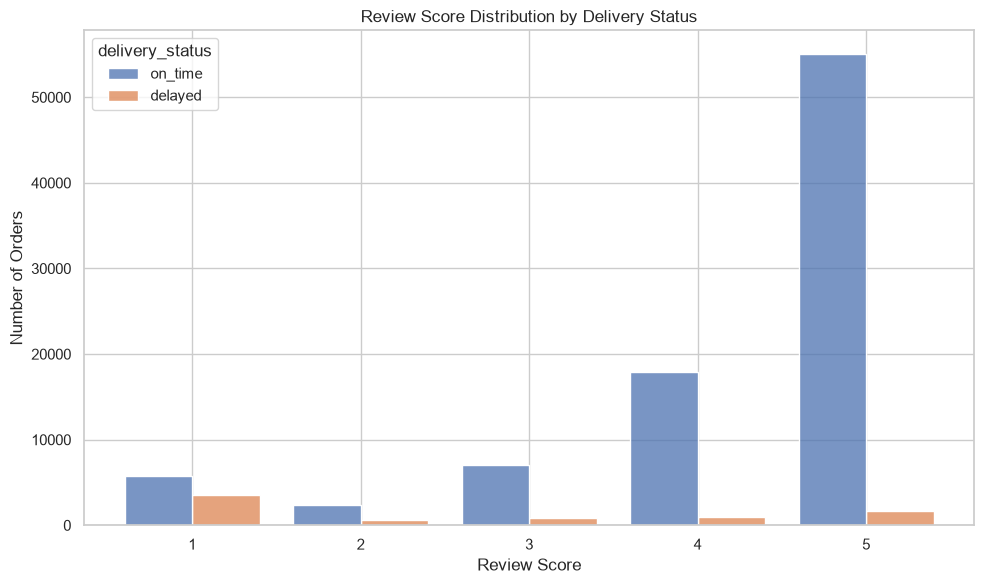

In [55]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=ttest_data,
    x="review_score",
    hue="delivery_status",
    discrete=True,
    multiple="dodge",
    shrink=0.8
)

plt.xlabel("Review Score")
plt.ylabel("Number of Orders")
plt.title("Review Score Distribution by Delivery Status")

plt.tight_layout()
plt.show()

## T-Test Assumption — Variance

Welch's t-test does not require equal population variances.

Levene's test is included as a diagnostic to determine whether
the two groups show evidence of unequal variance.

### Levene Hypotheses

H₀: The two groups have equal variances.

H₁: The two groups have different variances.

In [56]:
levene_ttest_stat, levene_ttest_p = levene(
    delayed_reviews,
    on_time_reviews,
    center="median"
)

print("Levene Statistic:", levene_ttest_stat)
print("Levene p-value:", levene_ttest_p)

if levene_ttest_p < ALPHA:
    print("Conclusion: Evidence of unequal variances.")
else:
    print("Conclusion: No strong evidence of unequal variances.")

Levene Statistic: 3379.5912930599693
Levene p-value: 0.0
Conclusion: Evidence of unequal variances.


## Welch Independent Two-Sample T-Test

In [57]:
t_statistic, t_pvalue = ttest_ind(
    delayed_reviews,
    on_time_reviews,
    equal_var=False,
    alternative="two-sided"
)

print("Welch t-statistic:", t_statistic)
print("p-value:", t_pvalue)

Welch t-statistic: -89.43412593397376
p-value: 0.0


In [58]:
mean_delayed = delayed_reviews.mean()
mean_on_time = on_time_reviews.mean()

mean_difference = mean_delayed - mean_on_time

n_delayed = len(delayed_reviews)
n_on_time = len(on_time_reviews)

var_delayed = delayed_reviews.var(ddof=1)
var_on_time = on_time_reviews.var(ddof=1)

standard_error = np.sqrt(
    (var_delayed / n_delayed)
    +
    (var_on_time / n_on_time)
)

welch_df = (
    (
        (var_delayed / n_delayed)
        +
        (var_on_time / n_on_time)
    ) ** 2
    /
    (
        ((var_delayed / n_delayed) ** 2) / (n_delayed - 1)
        +
        ((var_on_time / n_on_time) ** 2) / (n_on_time - 1)
    )
)

t_critical = stats.t.ppf(
    1 - ALPHA / 2,
    welch_df
)

ci_lower = mean_difference - t_critical * standard_error
ci_upper = mean_difference + t_critical * standard_error

print("Mean review score — delayed:", mean_delayed)
print("Mean review score — on time:", mean_on_time)
print("Mean difference:", mean_difference)
print("95% CI:", (ci_lower, ci_upper))
print("Welch degrees of freedom:", welch_df)

Mean review score — delayed: 2.565120836054866
Mean review score — on time: 4.29429466895016
Mean difference: -1.729173832895294
95% CI: (np.float64(-1.767074495795975), np.float64(-1.6912731699946129))
Welch degrees of freedom: 8301.221058549258


## Effect Size — Cohen's d

Statistical significance tells us whether the observed difference
is unlikely to be explained by sampling variation.

Cohen's d provides an estimate of the magnitude of the difference.

In [59]:
pooled_std = np.sqrt(
    (
        (n_delayed - 1) * var_delayed
        +
        (n_on_time - 1) * var_on_time
    )
    /
    (
        n_delayed + n_on_time - 2
    )
)

cohens_d = mean_difference / pooled_std

print("Cohen's d:", cohens_d)

Cohen's d: -1.4470715247489587


Statistical Decision

In [60]:
print("=== T-TEST RESULT ===")

if t_pvalue < ALPHA:
    print(
        "Statistical Decision: Reject H₀."
    )
    print(
        "There is statistically significant evidence that "
        "review scores differ between delayed and on-time orders."
    )
else:
    print(
        "Statistical Decision: Fail to reject H₀."
    )
    print(
        "There is insufficient statistical evidence that "
        "review scores differ between delayed and on-time orders."
    )

=== T-TEST RESULT ===
Statistical Decision: Reject H₀.
There is statistically significant evidence that review scores differ between delayed and on-time orders.


Business Result Table

In [61]:
ttest_result = pd.DataFrame({
    "test": ["Welch Independent T-Test"],
    "delayed_mean_review": [mean_delayed],
    "on_time_mean_review": [mean_on_time],
    "mean_difference": [mean_difference],
    "t_statistic": [t_statistic],
    "p_value": [t_pvalue],
    "confidence_interval_lower": [ci_lower],
    "confidence_interval_upper": [ci_upper],
    "cohens_d": [cohens_d],
    "significant_at_5pct": [t_pvalue < ALPHA]
})

display(ttest_result)

,test,delayed_mean_review,on_time_mean_review,mean_difference,t_statistic,p_value,confidence_interval_lower,confidence_interval_upper,cohens_d,significant_at_5pct
0,Welch Independent T-Test,2.5651,4.2943,-1.7292,-89.4341,0.0000,-1.7671,-1.6913,-1.4471,True


## Business Interpretation

Interpret the result using the following structure:

**Observation**

Compare the average review score of delayed and on-time orders.

**Statistical Evidence**

Use the t-statistic, p-value and 95% confidence interval.

**Business Meaning**

If the delayed-order review score is significantly lower, the result
provides statistical evidence of an association between delivery
performance and customer satisfaction.

**Important Limitation**

This test does not prove that delivery delay alone caused the lower
review score. Other factors may also influence customer satisfaction.

# Test 2 — Product Category vs Order Value

## Business Question

Does average order value differ significantly across different
product categories?

## Method

One-Way ANOVA

## Hypotheses

### Null Hypothesis (H₀)

All product-category mean order values are equal.

### Alternative Hypothesis (H₁)

At least one product category has a different mean order value.

## Important Methodological Choice

Only single-category orders are included.

For a multi-category order, assigning the entire order value to
every category would artificially duplicate the spending.

Therefore, the ANOVA uses orders containing products from exactly
one product category.

Create Category Mapping

In [62]:
translation_map = (
    pd.read_sql(
        "SELECT * FROM category_translation",
        engine
    )
    .drop_duplicates("product_category_name")
    .set_index("product_category_name")[
        "product_category_name_english"
    ]
)

product_category_map = (
    products
    .drop_duplicates("product_id")
    .set_index("product_id")[
        "product_category_name"
    ]
)

anova_items = order_items[
    [
        "order_id",
        "product_id",
        "price",
        "freight_value"
    ]
].copy()

anova_items["product_category_name"] = (
    anova_items["product_id"]
    .map(product_category_map)
)

anova_items["category_name"] = (
    anova_items["product_category_name"]
    .map(translation_map)
    .fillna("unknown")
)

print("Category mapping completed.")

Category mapping completed.


Identify Single-Category Orders

In [63]:
category_count_per_order = (
    anova_items
    .groupby("order_id")["category_name"]
    .nunique()
)

single_category_order_ids = (
    category_count_per_order[
        category_count_per_order == 1
    ].index
)

anova_ready = (
    anova_items[
        anova_items["order_id"].isin(
            single_category_order_ids
        )
    ]
    .groupby(
        ["order_id", "category_name"],
        as_index=False
    )
    .agg(
        order_value=("price", "sum"),
        freight_value=("freight_value", "sum")
    )
)

anova_ready["total_order_value"] = (
    anova_ready["order_value"]
    +
    anova_ready["freight_value"]
)

anova_ready = anova_ready[
    [
        "order_id",
        "category_name",
        "total_order_value"
    ]
]

anova_ready = anova_ready[
    anova_ready["category_name"] != "unknown"
]

print("ANOVA observations:", len(anova_ready))
print(
    "Categories:",
    anova_ready["category_name"].nunique()
)

ANOVA observations: 96470
Categories: 71


Category Descriptive Statistics

In [64]:
anova_descriptive = (
    anova_ready
    .groupby("category_name")["total_order_value"]
    .agg(
        orders="count",
        mean="mean",
        median="median",
        std="std"
    )
    .reset_index()
    .sort_values(
        "orders",
        ascending=False
    )
)

display(anova_descriptive.head(20))

,category_name,orders,mean,median,std
7,bed_bath_table,9213,131.7974,105.2800,110.9408
43,health_beauty,8764,163.3459,103.8900,202.1902
65,sports_leisure,7648,150.0002,110.9050,186.6361
15,computers_accessories,6637,158.3065,102.9700,218.9561
39,furniture_decor,6243,140.2852,102.8700,132.4912
49,housewares,5768,132.8713,87.7050,177.9042
70,watches_gifts,5584,232.6367,158.5200,271.4092
68,telephony,4172,94.1978,45.3000,151.5703
5,auto,3861,176.5855,110.8800,245.8125
69,toys,3835,144.8586,104.2800,143.9612


Group Size Check

In [65]:
anova_group_sizes = (
    anova_ready["category_name"]
    .value_counts()
    .sort_values()
)

display(anova_group_sizes.to_frame("orders"))

,orders
category_name,
security_and_services,2
fashion_childrens_clothes,6
la_cuisine,11
cds_dvds_musicals,12
arts_and_craftmanship,21
...,...
furniture_decor,6243
computers_accessories,6637
sports_leisure,7648


## ANOVA Assumption 1 — Independent Observations

Each order is represented once in the ANOVA dataset.

Because the analysis uses one observation per order, one customer's
order is not duplicated simply because it contains multiple products.

## ANOVA Assumption 2 — Variance Homogeneity

Levene's test is used to evaluate whether category variances are
approximately equal.

### Levene Hypotheses

H₀: Category variances are equal.

H₁: At least one category has a different variance.

Prepare ANOVA Groups

In [66]:
anova_groups = [
    group["total_order_value"].values
    for _, group in anova_ready.groupby("category_name")
    if len(group) >= 2
]

print("Number of ANOVA groups:", len(anova_groups))

Number of ANOVA groups: 71


Levene Test

In [67]:
levene_anova_stat, levene_anova_p = levene(
    *anova_groups,
    center="median"
)

print("Levene Statistic:", levene_anova_stat)
print("Levene p-value:", levene_anova_p)

if levene_anova_p < ALPHA:
    print(
        "Conclusion: Evidence that category variances "
        "are not equal."
    )
else:
    print(
        "Conclusion: No strong evidence that category "
        "variances differ."
    )

Levene Statistic: 61.42111648886127
Levene p-value: 0.0
Conclusion: Evidence that category variances are not equal.


## Welch One-Way ANOVA

Because Levene's test is used above to check variance homogeneity, the
choice of ANOVA method is based on that result.

If category variances are unequal, the standard one-way ANOVA is not
appropriate. Welch's one-way ANOVA is used instead because it does not
assume equal population variances.


In [68]:
# Welch one-way ANOVA
welch_anova_result = anova_oneway(
    anova_ready["total_order_value"].values,
    groups=anova_ready["category_name"].values,
    use_var="unequal",
    welch_correction=True
)

anova_statistic = welch_anova_result.statistic
anova_pvalue = welch_anova_result.pvalue
anova_df_num = welch_anova_result.df_num
anova_df_denom = welch_anova_result.df_denom

print("Welch ANOVA F-statistic:", anova_statistic)
print("Welch ANOVA numerator df:", anova_df_num)
print("Welch ANOVA denominator df:", anova_df_denom)
print("Welch ANOVA p-value:", anova_pvalue)


Welch ANOVA F-statistic: 75.81961771227508
Welch ANOVA numerator df: 70.0
Welch ANOVA denominator df: 862.1487531554551
Welch ANOVA p-value: 0.0


Eta Squared

In [69]:
grand_mean = anova_ready["total_order_value"].mean()

ss_between = sum(
    len(group) *
    (group["total_order_value"].mean() - grand_mean) ** 2
    for _, group in anova_ready.groupby("category_name")
)

ss_total = (
    (
        anova_ready["total_order_value"]
        - grand_mean
    ) ** 2
).sum()

eta_squared = ss_between / ss_total

print("Eta squared:", eta_squared)

Eta squared: 0.1006961279848225


## Post-Hoc Analysis

The variance-homogeneity assumption is violated when Levene's test is
significant. Therefore, the ordinary Tukey HSD procedure is not used
here because it relies on the equal-variance assumption.

Welch ANOVA determines whether at least one category mean differs, but
this notebook does not perform a heteroscedastic post-hoc comparison.
The result is therefore interpreted at the overall category level.


In [70]:
# Tukey HSD is intentionally not used because the Levene test
# indicates unequal variances. Welch ANOVA is the appropriate overall test.
tukey_result = None

print(
    "Ordinary Tukey HSD was not performed because the equal-variance "
    "assumption is violated. Welch ANOVA is reported instead."
)


Ordinary Tukey HSD was not performed because the equal-variance assumption is violated. Welch ANOVA is reported instead.


ANOVA Result

In [71]:
anova_result = pd.DataFrame({
    "test": ["Welch One-Way ANOVA"],
    "groups": [anova_ready["category_name"].nunique()],
    "observations": [len(anova_ready)],
    "f_statistic": [anova_statistic],
    "df_num": [anova_df_num],
    "df_denom": [anova_df_denom],
    "p_value": [anova_pvalue],
    "eta_squared": [eta_squared],
    "significant_at_5pct": [anova_pvalue < ALPHA]
})

display(anova_result)


,test,groups,observations,f_statistic,df_num,df_denom,p_value,eta_squared,significant_at_5pct
0,Welch One-Way ANOVA,71,96470,75.8196,70.0000,862.1488,0.0000,0.1007,True


## Business Interpretation

**Observation**

Compare average order values across product categories.

**Statistical Evidence**

Use the Welch ANOVA F-statistic, degrees of freedom, p-value and eta
squared effect size.

**If significant**

There is statistical evidence that average order value is not the same
across all product categories.

Because category variances are unequal, the analysis does not use
ordinary Tukey HSD post-hoc comparisons. The result should therefore be
reported as an overall difference across categories unless a suitable
heteroscedastic post-hoc method is added separately.

**Business Meaning**

Differences in spending across categories can help identify product
categories associated with higher or lower customer basket values.

**Important Limitation**

A significant Welch ANOVA result does not establish that product
category causes customers to spend a particular amount.


# Test 3 — Payment Method vs Order Outcome

## Business Question

Is there a statistically significant association between payment
method and order outcome?

## Method

Chi-Square Test of Independence

## Hypotheses

### Null Hypothesis (H₀)

Payment method and order outcome are independent.

### Alternative Hypothesis (H₁)

Payment method and order outcome are associated.

## Significance Level

α = 0.05

The full payment-method × order-status table is retained for descriptive
analysis. For the inferential test, order status is collapsed into two
business outcomes: `delivered` and `not_delivered`. The three `unknown`
payment-type orders are excluded from the inferential test because the
category is too sparse to provide a stable expected-frequency structure.


Primary Payment Method per Order

In [72]:
payment_by_order = (
    order_payments
    .groupby(
        ["order_id", "payment_type"],
        as_index=False
    )
    .agg(
        payment_value=("payment_value", "sum")
    )
    .sort_values(
        ["order_id", "payment_value"],
        ascending=[True, False]
    )
    .drop_duplicates("order_id")
)

order_status_map = (
    order_features
    .drop_duplicates("order_id")
    .set_index("order_id")["order_status"]
)

payment_order = payment_by_order[
    [
        "order_id",
        "payment_type",
        "payment_value"
    ]
].copy()

payment_order["order_status"] = (
    payment_order["order_id"]
    .map(order_status_map)
)

payment_order = payment_order.dropna(
    subset=[
        "payment_type",
        "order_status"
    ]
)

display(
    payment_order["payment_type"]
    .value_counts()
    .rename_axis("payment_type")
    .reset_index(name="orders")
)

,payment_type,orders
0,credit_card,74935
1,boleto,19784
2,voucher,3191
3,debit_card,1527
4,unknown,3


Descriptive Crosstab

In [73]:
payment_status_table = pd.crosstab(
    payment_order["payment_type"],
    payment_order["order_status"]
)

display(payment_status_table)

order_status,approved,canceled,created,delivered,invoiced,processing,shipped,unavailable
payment_type,,,,,,,,
boleto,0,95,2,19191,67,70,209,150
credit_card,2,432,3,72785,231,219,836,427
debit_card,0,7,0,1484,6,2,22,6
unknown,0,3,0,0,0,0,0,0
voucher,0,88,0,3017,10,10,40,26


Row Percentages

In [74]:
payment_status_percentage = (
    payment_status_table
    .div(
        payment_status_table.sum(axis=1),
        axis=0
    )
    * 100
)

display(
    payment_status_percentage.round(2)
)

order_status,approved,canceled,created,delivered,invoiced,processing,shipped,unavailable
payment_type,,,,,,,,
boleto,0.0000,0.4800,0.0100,97.0000,0.3400,0.3500,1.0600,0.7600
credit_card,0.0000,0.5800,0.0000,97.1300,0.3100,0.2900,1.1200,0.5700
debit_card,0.0000,0.4600,0.0000,97.1800,0.3900,0.1300,1.4400,0.3900
unknown,0.0000,100.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
voucher,0.0000,2.7600,0.0000,94.5500,0.3100,0.3100,1.2500,0.8100


## Chi-Square Contingency Table

The descriptive table above retains the original order-status categories.
For the inferential test, statuses are collapsed into a binary business
outcome so that sparse individual status categories do not create very
small expected frequencies.


## Prepare Inferential Dataset

The inferential outcome is:

- `delivered` → the order reached the customer
- `not_delivered` → every other recorded order status

Orders with `unknown` payment type are excluded from the inferential
test only; they remain in the descriptive analysis.


In [75]:
payment_known = payment_order[
    payment_order["payment_type"] != "unknown"
].copy()

payment_known["order_outcome"] = np.where(
    payment_known["order_status"].eq("delivered"),
    "delivered",
    "not_delivered"
)

chi_square_table = pd.crosstab(
    payment_known["payment_type"],
    payment_known["order_outcome"]
)

display(chi_square_table)


order_outcome,delivered,not_delivered
payment_type,,
boleto,19191,593
credit_card,72785,2150
debit_card,1484,43
voucher,3017,174


Chi-Square Test

In [76]:
chi2_statistic, chi2_pvalue, chi2_dof, expected = (
    chi2_contingency(chi_square_table)
)

expected_table = pd.DataFrame(
    expected,
    index=chi_square_table.index,
    columns=chi_square_table.columns
)

print("Chi-square statistic:", chi2_statistic)
print("p-value:", chi2_pvalue)
print("Degrees of freedom:", chi2_dof)

print("\nExpected Frequencies:")
display(expected_table.round(2))


Chi-square statistic: 70.90854041853385
p-value: 2.7270653215814977e-15
Degrees of freedom: 3

Expected Frequencies:


order_outcome,delivered,not_delivered
payment_type,,
boleto,"19,195.0800",588.9200
credit_card,"72,704.3700","2,230.6300"
debit_card,"1,481.5400",45.4600
voucher,"3,096.0100",94.9900


Check Expected Frequencies

In [77]:
minimum_expected = expected.min()

print(
    "Minimum expected frequency:",
    minimum_expected
)

if minimum_expected >= 5:
    print(
        "Chi-square expected-frequency assumption is satisfied."
    )
else:
    print(
        "Warning: At least one expected frequency is below 5. "
        "Interpret the chi-square result cautiously."
    )


Minimum expected frequency: 45.4551122821485
Chi-square expected-frequency assumption is satisfied.


## Effect Size — Cramér's V

A significant chi-square result indicates an association, but it
does not indicate how strong that association is.

Cramér's V provides an effect-size measure for categorical variables.

In [78]:
n_chi = chi_square_table.to_numpy().sum()

rows, columns = chi_square_table.shape

cramers_v = np.sqrt(
    chi2_statistic
    /
    (
        n_chi * min(rows - 1, columns - 1)
    )
)

print("Cramér's V:", cramers_v)

Cramér's V: 0.026703935254477052


Statistical Decision

In [79]:
print("=== CHI-SQUARE RESULT ===")

if chi2_pvalue < ALPHA:
    print("Statistical Decision: Reject H₀.")
    print(
        "There is statistically significant evidence of an association "
        "between payment method and delivered vs not-delivered outcome."
    )
else:
    print("Statistical Decision: Fail to reject H₀.")
    print(
        "There is insufficient statistical evidence of an association "
        "between payment method and delivered vs not-delivered outcome."
    )


=== CHI-SQUARE RESULT ===
Statistical Decision: Reject H₀.
There is statistically significant evidence of an association between payment method and delivered vs not-delivered outcome.


Chi-Square Result Table

In [80]:
chi_square_result = pd.DataFrame({
    "test": ["Chi-Square Test of Independence"],
    "observations": [n_chi],
    "chi_square": [chi2_statistic],
    "degrees_of_freedom": [chi2_dof],
    "p_value": [chi2_pvalue],
    "cramers_v": [cramers_v],
    "significant_at_5pct": [chi2_pvalue < ALPHA]
})

display(chi_square_result)


,test,observations,chi_square,degrees_of_freedom,p_value,cramers_v,significant_at_5pct
0,Chi-Square Test of Independence,99437,70.9085,3,0.0000,0.0267,True


## Business Interpretation

**Observation**

Compare delivered vs not-delivered order outcomes across known payment
methods.

**Statistical Evidence**

Use the chi-square statistic, p-value and Cramér's V.

**Business Meaning**

If statistically significant, payment method and delivery outcome show
an association in this dataset.

This may help identify payment methods whose delivery outcomes differ
from the overall pattern.

**Important Limitation**

Association does not establish that payment method causes a particular
order outcome. The inferential test also uses a collapsed outcome and
excludes the three `unknown` payment-type orders.


# Test 4 — Actual Delivery Delay vs Review Score

## Business Question

Among orders that were actually delayed, as the number of days late
increases, is customer review score associated with the delay?

## Method

Spearman Rank Correlation

## Why Spearman?

Review score is an ordinal variable from 1 to 5, while delivery delay
may not follow a normal distribution. Spearman correlation measures the
strength and direction of a monotonic relationship without requiring
normally distributed variables.

## Hypotheses

### Null Hypothesis (H₀)

There is no monotonic association between actual delivery delay and
review score among delayed orders.

### Alternative Hypothesis (H₁)

There is a monotonic association between actual delivery delay and
review score among delayed orders.

## Important Methodological Choice

`delivery_delay_days` is a signed feature: negative values represent
early delivery relative to the estimated date. Because this test asks
whether greater actual lateness is associated with review score, only
orders classified as `delayed` with positive delay days are included.


Prepare Correlation Data

In [81]:
spearman_data = (
    order_features[
        [
            "order_id",
            "delivery_status",
            "delivery_delay_days",
            "review_score"
        ]
    ]
    .query("delivery_status == 'delayed' and delivery_delay_days > 0")
    .dropna(
        subset=[
            "delivery_delay_days",
            "review_score"
        ]
    )
    .copy()
)

print(
    "Delayed-order observations:",
    len(spearman_data)
)

print(
    "Minimum positive delay:",
    spearman_data["delivery_delay_days"].min()
)

print(
    "Maximum delay:",
    spearman_data["delivery_delay_days"].max()
)

display(
    spearman_data[
        [
            "delivery_delay_days",
            "review_score"
        ]
    ].describe()
)


Delayed-order observations: 7655
Minimum positive delay: 0.01
Maximum delay: 188.98


,delivery_delay_days,review_score
count,"7,655.0000","7,655.0000"
mean,9.4533,2.5651
std,13.7756,1.6576
min,0.0100,1.0000
25%,1.8600,1.0000
50%,5.7900,2.0000
75%,11.7700,4.0000
max,188.9800,5.0000


Spearman Test

In [82]:
spearman_rho, spearman_pvalue = spearmanr(
    spearman_data["delivery_delay_days"],
    spearman_data["review_score"]
)

print("Spearman rho:", spearman_rho)
print("p-value:", spearman_pvalue)

Spearman rho: -0.5207877294510622
p-value: 0.0


Visualization

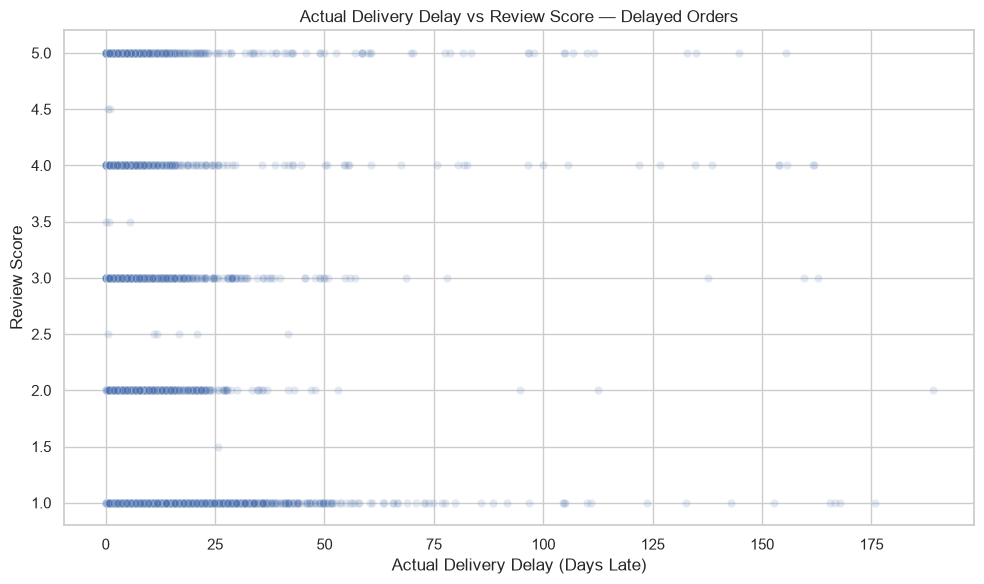

In [83]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=spearman_data,
    x="delivery_delay_days",
    y="review_score",
    alpha=0.15
)

plt.xlabel("Actual Delivery Delay (Days Late)")
plt.ylabel("Review Score")
plt.title("Actual Delivery Delay vs Review Score — Delayed Orders")

plt.tight_layout()
plt.show()


In [84]:
print("=== SPEARMAN CORRELATION RESULT ===")

if spearman_pvalue < ALPHA:
    print("Statistical Decision: Reject H₀.")
    print(
        "There is statistically significant evidence of a monotonic "
        "association between actual delivery delay and review score "
        "among delayed orders."
    )
else:
    print("Statistical Decision: Fail to reject H₀.")
    print(
        "There is insufficient statistical evidence of a monotonic "
        "association between actual delivery delay and review score "
        "among delayed orders."
    )


=== SPEARMAN CORRELATION RESULT ===
Statistical Decision: Reject H₀.
There is statistically significant evidence of a monotonic association between actual delivery delay and review score among delayed orders.


## Business Interpretation

Interpret the sign of Spearman's rho:

- Negative rho → greater lateness tends to be associated with lower review scores.
- Positive rho → greater lateness tends to be associated with higher review scores.
- Rho close to zero → weak monotonic association.

### Correlation vs Causation

Even if the correlation is statistically significant, it does not prove
that delivery delay caused the change in customer satisfaction.

Other factors such as product quality, seller performance, shipping
distance, price, and customer expectations may also influence review
scores.

Therefore, the result should be described as an **association**, not as
proof of causation. The analysis specifically measures variation in
actual lateness among orders that were already classified as delayed.


# Test 5 — Basket Size vs Order Value

## Business Question

Is there a statistically significant linear relationship between
the number of items in an order and the total order value?

## Method

Pearson Correlation

## Business Objective

Understand whether larger baskets are associated with higher
customer spending per order.

## Hypotheses

### Null Hypothesis (H₀)

There is no linear relationship between basket size and order value.

### Alternative Hypothesis (H₁)

There is a linear relationship between basket size and order value.

Prepare Pearson Data

In [85]:
pearson_data = (
    order_features[
        [
            "order_id",
            "total_items_per_order",
            "total_order_value"
        ]
    ]
    .dropna(
        subset=[
            "total_items_per_order",
            "total_order_value"
        ]
    )
    .copy()
)

print(
    "Observations:",
    len(pearson_data)
)

display(
    pearson_data[
        [
            "total_items_per_order",
            "total_order_value"
        ]
    ].describe()
)

Observations: 99441


,total_items_per_order,total_order_value
count,"99,441.0000","99,441.0000"
mean,1.1328,159.3262
std,0.5457,220.0588
min,0.0000,0.0000
25%,1.0000,61.0500
50%,1.0000,104.5600
75%,1.0000,176.0000
max,21.0000,"13,664.0800"


Pearson Test

In [86]:
pearson_r, pearson_pvalue = pearsonr(
    pearson_data["total_items_per_order"],
    pearson_data["total_order_value"]
)

print("Pearson correlation:", pearson_r)
print("p-value:", pearson_pvalue)

Pearson correlation: 0.19734860840164278
p-value: 0.0


Visualization

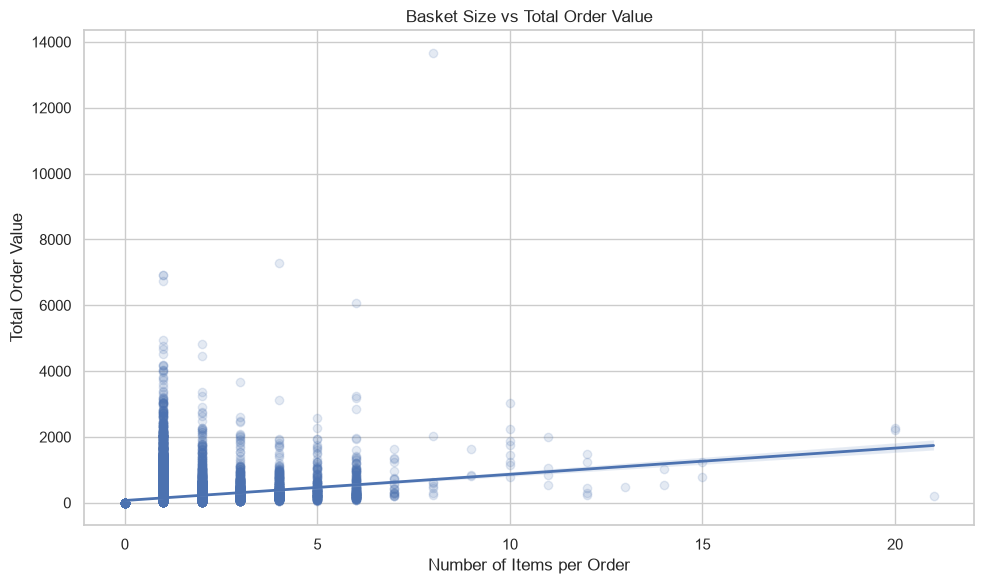

In [87]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=pearson_data,
    x="total_items_per_order",
    y="total_order_value",
    scatter_kws={"alpha": 0.15},
    line_kws={"linewidth": 2}
)

plt.xlabel("Number of Items per Order")
plt.ylabel("Total Order Value")
plt.title("Basket Size vs Total Order Value")

plt.tight_layout()
plt.show()

Decision

In [88]:
print("=== PEARSON CORRELATION RESULT ===")

if pearson_pvalue < ALPHA:

    print(
        "Statistical Decision: Reject H₀."
    )

    print(
        "There is statistically significant evidence "
        "of a linear relationship between basket size "
        "and total order value."
    )

else:

    print(
        "Statistical Decision: Fail to reject H₀."
    )

    print(
        "There is insufficient statistical evidence "
        "of a linear relationship between basket size "
        "and total order value."
    )

=== PEARSON CORRELATION RESULT ===
Statistical Decision: Reject H₀.
There is statistically significant evidence of a linear relationship between basket size and total order value.


## Business Interpretation

A positive correlation indicates that larger baskets tend to be
associated with higher order values.

This can support business analysis around:

- basket expansion
- cross-selling
- product bundling
- merchandising
- increasing items per transaction

However, correlation alone does not establish that increasing
basket size will necessarily cause higher revenue.

# Statistical Analysis Summary

The following table consolidates the results of all statistical
tests performed in this notebook.

The purpose is to provide a single view of:

- Test used
- Business question
- Statistic
- p-value
- Effect size
- Statistical decision

In [89]:
statistical_summary = pd.DataFrame([
    {
        "analysis": "Delivery Status vs Review Score",
        "test": "Welch T-Test",
        "statistic": t_statistic,
        "p_value": t_pvalue,
        "effect_size": cohens_d,
        "effect_measure": "Cohen's d",
        "significant": t_pvalue < ALPHA
    },
    {
        "analysis": "Product Category vs Order Value",
        "test": "Welch One-Way ANOVA",
        "statistic": anova_statistic,
        "p_value": anova_pvalue,
        "effect_size": eta_squared,
        "effect_measure": "Eta Squared",
        "significant": anova_pvalue < ALPHA
    },
    {
        "analysis": "Payment Method vs Order Status",
        "test": "Chi-Square",
        "statistic": chi2_statistic,
        "p_value": chi2_pvalue,
        "effect_size": cramers_v,
        "effect_measure": "Cramér's V",
        "significant": chi2_pvalue < ALPHA
    },
    {
        "analysis": "Delivery Delay vs Review Score",
        "test": "Spearman Correlation",
        "statistic": spearman_rho,
        "p_value": spearman_pvalue,
        "effect_size": spearman_rho,
        "effect_measure": "Spearman rho",
        "significant": spearman_pvalue < ALPHA
    },
    {
        "analysis": "Basket Size vs Order Value",
        "test": "Pearson Correlation",
        "statistic": pearson_r,
        "p_value": pearson_pvalue,
        "effect_size": pearson_r,
        "effect_measure": "Pearson r",
        "significant": pearson_pvalue < ALPHA
    }
])

display(
    statistical_summary.round(6)
)

,analysis,test,statistic,p_value,effect_size,effect_measure,significant
0,Delivery Status vs Review Score,Welch T-Test,-89.4341,0.0000,-1.4471,Cohen's d,True
1,Product Category vs Order Value,Welch One-Way ANOVA,75.8196,0.0000,0.1007,Eta Squared,True
2,Payment Method vs Order Status,Chi-Square,70.9085,0.0000,0.0267,Cramér's V,True
3,Delivery Delay vs Review Score,Spearman Correlation,-0.5208,0.0000,-0.5208,Spearman rho,True
4,Basket Size vs Order Value,Pearson Correlation,0.1973,0.0000,0.1973,Pearson r,True


In [90]:
statistical_summary["decision"] = np.where(
    statistical_summary["p_value"] < ALPHA,
    "Reject H0",
    "Fail to Reject H0"
)

display(statistical_summary)

,analysis,test,statistic,p_value,effect_size,effect_measure,significant,decision
0,Delivery Status vs Review Score,Welch T-Test,-89.4341,0.0000,-1.4471,Cohen's d,True,Reject H0
1,Product Category vs Order Value,Welch One-Way ANOVA,75.8196,0.0000,0.1007,Eta Squared,True,Reject H0
2,Payment Method vs Order Status,Chi-Square,70.9085,0.0000,0.0267,Cramér's V,True,Reject H0
3,Delivery Delay vs Review Score,Spearman Correlation,-0.5208,0.0000,-0.5208,Spearman rho,True,Reject H0
4,Basket Size vs Order Value,Pearson Correlation,0.1973,0.0000,0.1973,Pearson r,True,Reject H0


# Overall Statistical Business Insights

## 1. Delivery Performance & Customer Satisfaction

The Welch independent two-sample t-test evaluates whether review
scores differ between delayed and on-time orders.

The result should be interpreted using:

- average review score by delivery status
- mean difference
- 95% confidence interval
- p-value
- Cohen's d

If the delayed group has a significantly lower review score,
delivery performance should be considered an important customer
experience indicator.

However, the result demonstrates statistical association rather
than proving causation.

---

## 2. Product Category & Customer Spending

Welch one-way ANOVA evaluates whether average order value differs
across product categories.

If significant, the result indicates that customer spending is
not uniform across categories.

Tukey HSD identifies the category pairs responsible for the
differences.

This can support category-level merchandising and sales analysis.

---

## 3. Payment Method & Order Outcome

The chi-square test evaluates whether payment method and order
status are statistically associated.

If significant, payment methods show different order-status
distributions in the observed dataset.

This can help identify payment methods that warrant additional
operational monitoring.

The result should not be interpreted as payment method causing
order outcomes.

---

## 4. Delivery Delay & Customer Satisfaction

Spearman correlation evaluates whether increasing delivery delay
is associated with a monotonic change in review score.

A negative and statistically significant correlation would indicate
that greater delays tend to coincide with lower review scores.

This strengthens the delivery/customer-experience analysis by
examining the degree of delay rather than only the delayed vs
on-time classification.

---

## 5. Basket Size & Order Value

Pearson correlation evaluates the relationship between the number
of items purchased and total order value.

A positive statistically significant relationship indicates that
larger baskets tend to have higher order values.

This can support business analysis around cross-selling, bundling,
and basket expansion.

---

## Final Statistical Principle

Statistical significance identifies relationships that are unlikely
to be explained by sampling variation alone at the chosen
significance level.

It does not automatically imply:

- causation
- business importance
- large effect
- guaranteed future performance

Therefore, statistical results should always be interpreted together
with effect size, descriptive statistics, EDA findings, and business
context.

In [91]:
final_decisions = statistical_summary[
    [
        "analysis",
        "test",
        "p_value",
        "effect_size",
        "effect_measure",
        "decision"
    ]
].copy()

final_decisions["p_value"] = (
    final_decisions["p_value"].map(
        lambda x: f"{x:.6g}"
    )
)

final_decisions["effect_size"] = (
    final_decisions["effect_size"].map(
        lambda x: f"{x:.4f}"
    )
)

display(final_decisions)

,analysis,test,p_value,effect_size,effect_measure,decision
0,Delivery Status vs Review Score,Welch T-Test,0,-1.4471,Cohen's d,Reject H0
1,Product Category vs Order Value,Welch One-Way ANOVA,0,0.1007,Eta Squared,Reject H0
2,Payment Method vs Order Status,Chi-Square,2.72707e-15,0.0267,Cramér's V,Reject H0
3,Delivery Delay vs Review Score,Spearman Correlation,0,-0.5208,Spearman rho,Reject H0
4,Basket Size vs Order Value,Pearson Correlation,0,0.1973,Pearson r,Reject H0
